In [1]:
import sys
import os
# Get the path to two levels above the current notebook
three_levels_up = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
sys.path.append(three_levels_up)
# Optional: if needed from config/config.py
from config.config import path
sys.path.append(path)
from results_functions import load_results, plot_results_delta_levels_by_training_size_grid, plot_results_delta_levels_by_learner_grid, plot_results_delta_levels_by_model_grid, plot_results_delta_levels_by_stage_grid
from src.utils.mini_tools import save_data, load_data

In [2]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

## Plan for figures: 
    - first figure = grid, with different training sizes is one part of grid, confounding on x-axis, and only CLIPPS-S, leoni, and branchi
    - second figure = grid, with different meta-learners compared as one part of grid, confounding on x-axis, so only comparing separate opt vs combined


Training size: 10000

Method: dtr-S-reg-R

Delta: 0.9
  Avg uplift: 4.3862, SE: 0.0069
Delta: 0.95
  Avg uplift: 4.1965, SE: 0.0223
Delta: 0.99
  Avg uplift: 2.3144, SE: 0.2749

Method: separate-S-reg-none

Delta: 0.9
  Avg uplift: 3.2429, SE: 0.0026
Delta: 0.95
  Avg uplift: 3.2267, SE: 0.0019
Delta: 0.99
  Avg uplift: 2.9772, SE: 0.0108

Method: kmeans_q

Delta: 0.9
  Avg uplift: 3.9816, SE: 0.0000
Delta: 0.95
  Avg uplift: 3.9816, SE: 0.0000
Delta: 0.99
  Avg uplift: 3.9816, SE: 0.0000

Method: random

Delta: 0.9
  Avg uplift: -1.5824, SE: 0.0442
Delta: 0.95
  Avg uplift: -1.5824, SE: 0.0442
Delta: 0.99
  Avg uplift: -1.5824, SE: 0.0442

Method: optimal

Delta: 0.9
  Avg uplift: 4.4029, SE: 0.0000
Delta: 0.95
  Avg uplift: 4.4029, SE: 0.0000
Delta: 0.99
  Avg uplift: 4.4029, SE: 0.0000

Training size: 10000

Method: dtr-S-reg-R

Delta: 0.9
  Avg uplift: 5.0838, SE: 0.0108
Delta: 0.95
  Avg uplift: 5.0300, SE: 0.0061
Delta: 0.99
  Avg uplift: 4.1369, SE: 0.0934

Method: separate-S-r

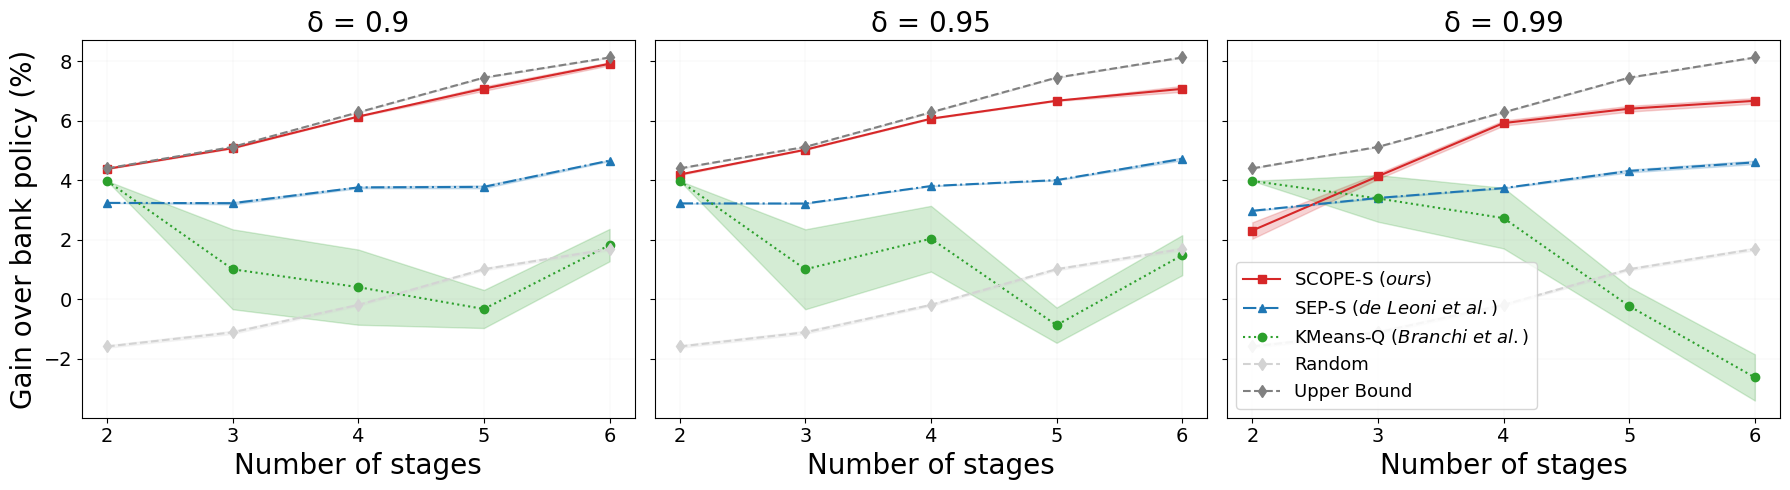

In [23]:
dataset = 'bpic17'
n_stages_list = [2, 3, 4, 5, 6]
# delta_fixed = 0.95
delta_fixed = 0.99
training_sizes = [10000]
num_iterations = 10
# delta_levels = [0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]
delta_levels = [0.9, 0.95, 0.99]

separate_list = ["separate-S-reg-none", "separate-T-reg-none", "separate-RAS-reg-none", "separate-RAT-reg-none"]
separate_list_simple = ["separate-S-reg-none", "separate-T-reg-none"]
separate_list_S = ["separate-RAS-reg-none"]
separate_list_T = ["separate-RAT-reg-none"]

reg_list = ["dtr-S-reg-R", "dtr-T-reg-R", "dtr-RAS-reg-R", "dtr-RAT-reg-R"]
reg_list_simple = ["dtr-S-reg-R", "dtr-T-reg-R"]
reg_list_S = ["dtr-RAS-reg-R"]
reg_list_T = ["dtr-RAT-reg-R"]

class_list = ["dtr-RAS-class-R", "dtr-RAT-class-R"]
class_list_S = ["dtr-RAS-class-R"]
class_list_T = ["dtr-RAT-class-R"]

kmeans_q_list = ["kmeans_q"]

baseslines = ["random", "optimal"]

methods_main =  ["dtr-S-reg-R"] + ["separate-S-reg-none"] + ["kmeans_q"] + baseslines
model_category = "ml"
cross_fit = False

stage_results_dict = {}
stage_avg_uplift_dict = {}
stage_se_uplift_dict = {}

for stage in n_stages_list:
    results_dict, avg_uplift_dict, se_uplift_dict = load_results(training_sizes=training_sizes, delta_levels=delta_levels, methods=methods_main, model_category=model_category, cross_fit=cross_fit, num_iterations=num_iterations, n_stages=stage, dataset=dataset)
    stage_results_dict[stage] = results_dict
    stage_avg_uplift_dict[stage] = avg_uplift_dict
    stage_se_uplift_dict[stage] = se_uplift_dict

print(stage_avg_uplift_dict)

plot_results_delta_levels_by_stage_grid(avg_uplift_dict=stage_avg_uplift_dict, se_uplift_dict=stage_se_uplift_dict, methods=methods_main, n_stages_list=n_stages_list, delta_levels=delta_levels)

xgb

Training size: 1000

Method: dtr-S-reg-R

Delta: 0.9
  Avg uplift: 232.9903, SE: 2.4092
Delta: 0.91
  Avg uplift: 243.2497, SE: 3.0862
Delta: 0.92
  Avg uplift: 232.6540, SE: 3.3606
Delta: 0.93
  Avg uplift: 218.9421, SE: 5.8419
Delta: 0.94
  Avg uplift: 214.7706, SE: 4.0469
Delta: 0.95
  Avg uplift: 214.4303, SE: 8.9136
Delta: 0.96
  Avg uplift: 247.0993, SE: 3.3877
Delta: 0.97
  Avg uplift: 230.7583, SE: 3.1475
Delta: 0.98
  Avg uplift: 214.6008, SE: 3.7693
Delta: 0.99
  Avg uplift: 148.0136, SE: 3.8630

Method: separate-S-reg-none

Delta: 0.9
  Avg uplift: 219.8636, SE: 2.5504
Delta: 0.91
  Avg uplift: 216.7909, SE: 3.3377
Delta: 0.92
  Avg uplift: 203.7568, SE: 3.5253
Delta: 0.93
  Avg uplift: 199.0741, SE: 2.5493
Delta: 0.94
  Avg uplift: 183.3049, SE: 1.8497
Delta: 0.95
  Avg uplift: 192.4661, SE: 5.5704
Delta: 0.96
  Avg uplift: 233.2368, SE: 4.8870
Delta: 0.97
  Avg uplift: 221.8995, SE: 5.1757
Delta: 0.98
  Avg uplift: 198.6773, SE: 6.1557
Delta: 0.99
  Avg uplift: 192.87

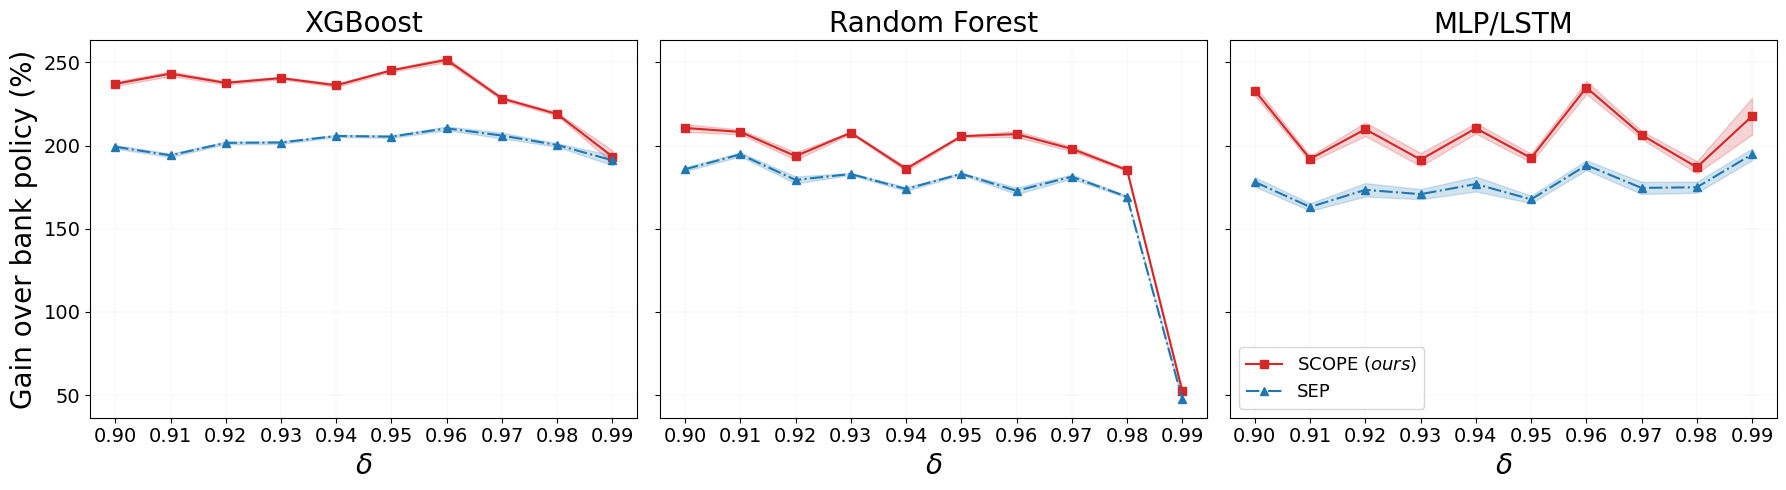

In [24]:
training_sizes = [1000, 10000, 50000]
# training_sizes = [1000, 10000, 20000, 50000]
# training_sizes = [500, 1000, 10000, 50000]
num_iterations = 10
# delta_levels = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.99]
# delta_levels = [0.8, 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87, 0.88, 0.89, 0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]
# delta_levels = [0.75, 0.8, 0.85, 0.9, 0.95, 0.99]
delta_levels = [0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]
# delta_levels = [0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98]
# delta_levels = [0.75, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]

separate_list = ["separate-S-reg-none", "separate-T-reg-none", "separate-RAS-reg-none", "separate-RAT-reg-none"]
separate_list_simple = ["separate-S-reg-none", "separate-T-reg-none"]
separate_list_S = ["separate-RAS-reg-none"]
separate_list_T = ["separate-RAT-reg-none"]

reg_list = ["dtr-S-reg-R", "dtr-T-reg-R", "dtr-RAS-reg-R", "dtr-RAT-reg-R"]
reg_list_simple = ["dtr-S-reg-R", "dtr-T-reg-R"]
reg_list_S = ["dtr-RAS-reg-R"]
reg_list_T = ["dtr-RAT-reg-R"]

class_list = ["dtr-RAS-class-R", "dtr-RAT-class-R"]
class_list_S = ["dtr-RAS-class-R"]
class_list_T = ["dtr-RAT-class-R"]

kmeans_q_list = ["kmeans_q"]

baseslines = ["random", "optimal"]

# concatenate
# methods = kmeans_q_list + separate_list + reg_list + class_list
# methods = separate_list_S + reg_list_S + class_list_S
# methods = separate_list_simple + separate_list_S + reg_list_simple + reg_list_S + kmeans_q_list + baseslines
# methods = ["separate-T-reg-none"] + separate_list_S + reg_list_simple + reg_list_S + class_list_S + baseslines

# methods_main =  ["dtr-S-reg-R"] + ["separate-S-reg-none"] + ["kmeans_q"] + baseslines
methods_main =  ["dtr-S-reg-R"] + ["separate-S-reg-none"]
# methods_main =  ["dtr-S-reg-R"] + ["separate-S-reg-none"] + baseslines
# methods_main =  reg_list_simple + reg_list_S + separate_list_simple + separate_list_S + baseslines
# methods_total =  reg_list_simple + reg_list_S + separate_list_simple + separate_list_S + ["kmeans_q"] + baseslines
methods_total =  ["dtr-S-reg-R"] + ["separate-S-reg-none"]
# methods_total =  reg_list_simple + reg_list_S + separate_list_simple + separate_list_S + baseslines
cross_fit = False
calc_results = True
# calc_results = False

model_specifics = ["xgb", "rf", "lstm"]
model_spec_dict_avg = {}
model_spec_dict_se = {}
if calc_results:
    for model_specific in model_specifics:
        if model_specific == "kmeans_q":
            model_category = model_specific
        elif model_specific in ["vanilla_nn", "lstm"]:
            model_category = "dl"
        else:
            model_category = "ml"
        
        print(model_specific)
        results_dict, avg_uplift_dict, se_uplift_dict = load_results(training_sizes=training_sizes, delta_levels=delta_levels, 
                                                                    methods=methods_total, model_category=model_category, 
                                                                    cross_fit=cross_fit, num_iterations=num_iterations, 
                                                                    model_specific=model_specific,
                                                                    )
        model_spec_dict_avg[model_specific] = avg_uplift_dict
        model_spec_dict_se[model_specific] = se_uplift_dict
    # save the dicts
    # save_data(results_dict, os.path.join(f"results_dict_{training_size}.pkl"))
    # save_data(avg_uplift_dict, os.path.join(f"avg_uplift_dict_{training_size}.pkl"))
    # save_data(se_uplift_dict, os.path.join(f"se_uplift_dict_{training_size}.pkl"))

# results_dict = load_data(os.path.join(f"results_dict_{training_size}.pkl"))
# avg_uplift_dict = load_data(os.path.join(f"avg_uplift_dict_{training_size}.pkl"))
# se_uplift_dict = load_data(os.path.join(f"se_uplift_dict_{training_size}.pkl"))

print(model_spec_dict_avg)

plot_results_delta_levels_by_model_grid(model_spec_dict_avg=model_spec_dict_avg, model_spec_dict_se=model_spec_dict_se, delta_levels=delta_levels, training_size=10000)


Training size: 1000

Method: dtr-S-reg-R

Delta: 0.9
  Avg uplift: 232.9903, SE: 2.4092
Delta: 0.91
  Avg uplift: 243.2497, SE: 3.0862
Delta: 0.92
  Avg uplift: 232.6540, SE: 3.3606
Delta: 0.93
  Avg uplift: 218.9421, SE: 5.8419
Delta: 0.94
  Avg uplift: 214.7706, SE: 4.0469
Delta: 0.95
  Avg uplift: 214.4303, SE: 8.9136
Delta: 0.96
  Avg uplift: 247.0993, SE: 3.3877
Delta: 0.97
  Avg uplift: 230.7583, SE: 3.1475
Delta: 0.98
  Avg uplift: 214.6008, SE: 3.7693
Delta: 0.99
  Avg uplift: 148.0136, SE: 3.8630

Method: dtr-T-reg-R

Delta: 0.9
  Avg uplift: 190.9088, SE: 1.1668
Delta: 0.91
  Avg uplift: 175.1068, SE: 2.2628
Delta: 0.92
  Avg uplift: 160.4313, SE: 2.4092
Delta: 0.93
  Avg uplift: 160.7769, SE: 2.7497
Delta: 0.94
  Avg uplift: 138.9593, SE: 1.6061
Delta: 0.95
  Avg uplift: 142.6980, SE: 2.7456
Delta: 0.96
  Avg uplift: 110.7985, SE: 3.0621
Delta: 0.97
  Avg uplift: 83.3605, SE: 7.2462
Delta: 0.98
  Avg uplift: 77.2876, SE: 7.9498
Delta: 0.99
  Avg uplift: 49.3332, SE: 9.6682


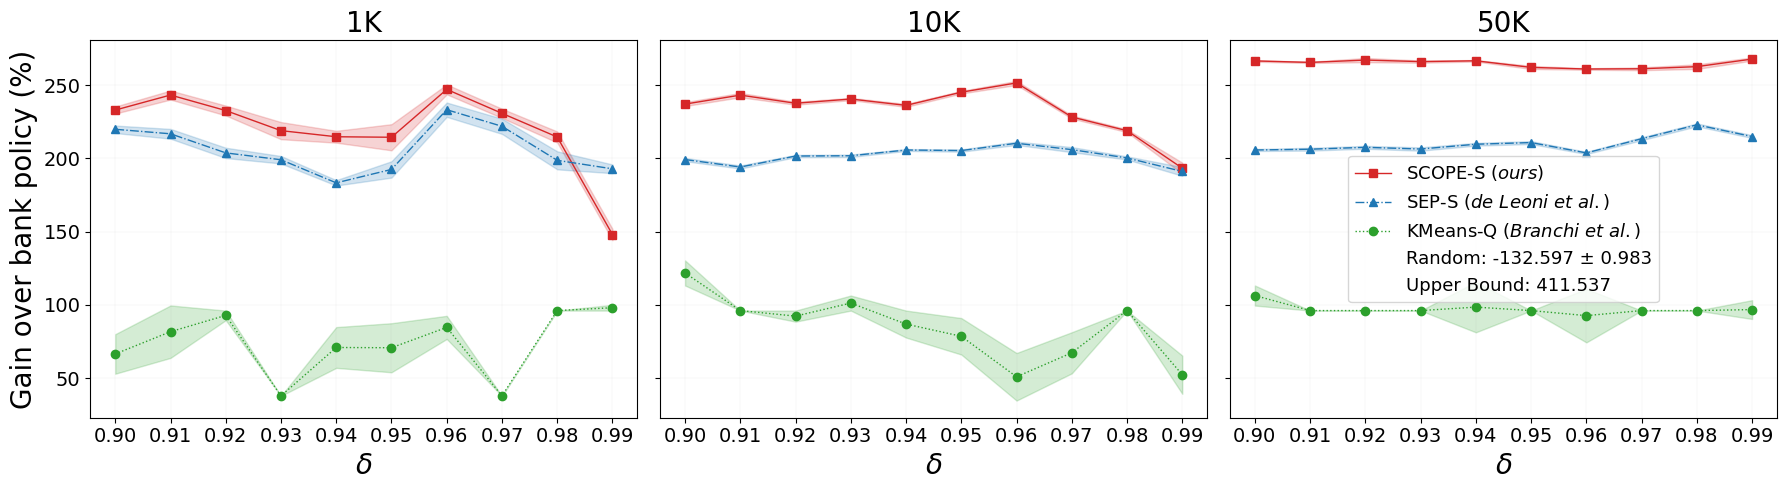

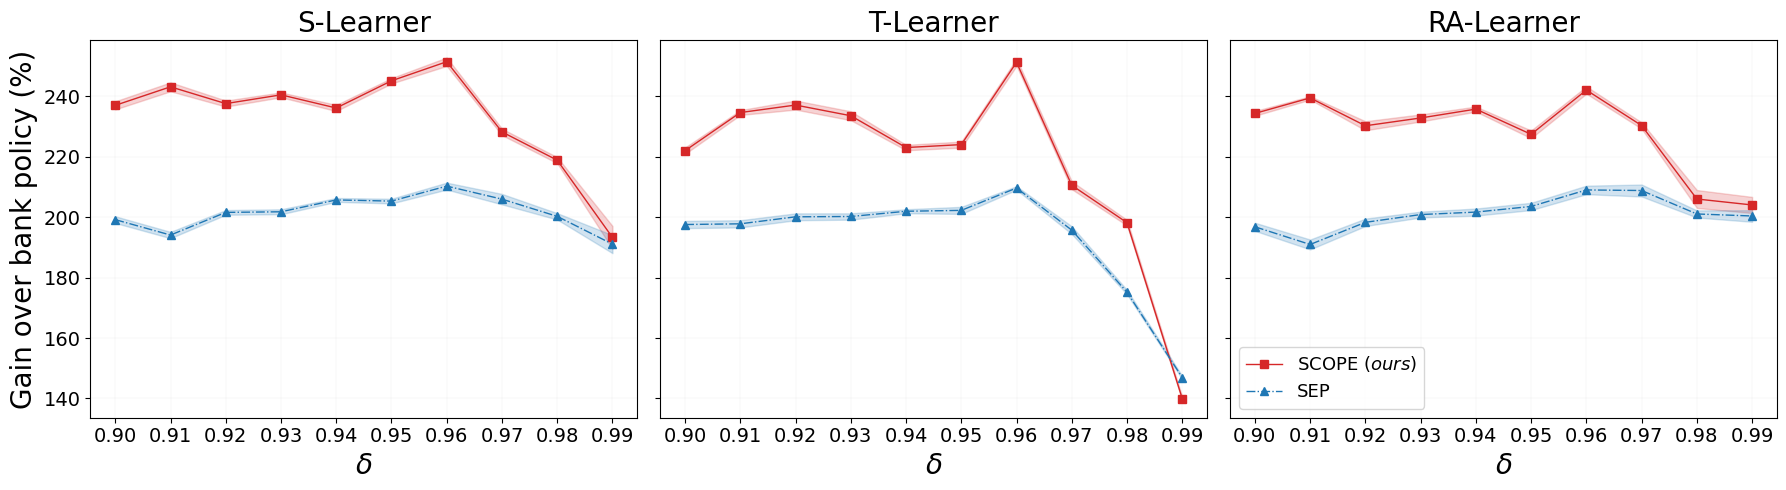

In [25]:
training_sizes = [1000, 10000, 50000]
# training_sizes = [1000, 10000, 20000, 50000]
# training_sizes = [500, 1000, 10000, 50000]
num_iterations = 10
# delta_levels = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.99]
# delta_levels = [0.8, 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87, 0.88, 0.89, 0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]
# delta_levels = [0.75, 0.8, 0.85, 0.9, 0.95, 0.99]
delta_levels = [0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]
# delta_levels = [0.75, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]

separate_list = ["separate-S-reg-none", "separate-T-reg-none", "separate-RAS-reg-none", "separate-RAT-reg-none"]
separate_list_simple = ["separate-S-reg-none", "separate-T-reg-none"]
separate_list_S = ["separate-RAS-reg-none"]
separate_list_T = ["separate-RAT-reg-none"]

reg_list = ["dtr-S-reg-R", "dtr-T-reg-R", "dtr-RAS-reg-R", "dtr-RAT-reg-R"]
reg_list_simple = ["dtr-S-reg-R", "dtr-T-reg-R"]
reg_list_S = ["dtr-RAS-reg-R"]
reg_list_T = ["dtr-RAT-reg-R"]

class_list = ["dtr-RAS-class-R", "dtr-RAT-class-R"]
class_list_S = ["dtr-RAS-class-R"]
class_list_T = ["dtr-RAT-class-R"]

kmeans_q_list = ["kmeans_q"]

baseslines = ["random", "optimal"]

# concatenate
# methods = kmeans_q_list + separate_list + reg_list + class_list
# methods = separate_list_S + reg_list_S + class_list_S
# methods = separate_list_simple + separate_list_S + reg_list_simple + reg_list_S + kmeans_q_list + baseslines
# methods = ["separate-T-reg-none"] + separate_list_S + reg_list_simple + reg_list_S + class_list_S + baseslines

methods_main =  ["dtr-S-reg-R"] + ["separate-S-reg-none"] + ["kmeans_q"] + baseslines
# methods_main =  ["dtr-S-reg-R"] + ["separate-S-reg-none"] + baseslines
# methods_main =  reg_list_simple + reg_list_S + separate_list_simple + separate_list_S + baseslines
methods_total =  reg_list_simple + reg_list_S + separate_list_simple + separate_list_S + ["kmeans_q"] + baseslines
# methods_total =  reg_list_simple + reg_list_S + separate_list_simple + separate_list_S + baseslines
model_category = "ml"
cross_fit = False
calc_results = True
# calc_results = False

if calc_results:
    results_dict, avg_uplift_dict, se_uplift_dict = load_results(training_sizes=training_sizes, delta_levels=delta_levels, methods=methods_total, model_category=model_category, cross_fit=cross_fit, num_iterations=num_iterations)
    # save the dicts
    # save_data(results_dict, os.path.join(f"results_dict_{training_size}.pkl"))
    # save_data(avg_uplift_dict, os.path.join(f"avg_uplift_dict_{training_size}.pkl"))
    # save_data(se_uplift_dict, os.path.join(f"se_uplift_dict_{training_size}.pkl"))

# results_dict = load_data(os.path.join(f"results_dict_{training_size}.pkl"))
# avg_uplift_dict = load_data(os.path.join(f"avg_uplift_dict_{training_size}.pkl"))
# se_uplift_dict = load_data(os.path.join(f"se_uplift_dict_{training_size}.pkl"))

plot_results_delta_levels_by_training_size_grid(avg_uplift_dict=avg_uplift_dict, se_uplift_dict=se_uplift_dict, methods=methods_main, delta_levels=delta_levels, training_sizes=training_sizes)

plot_results_delta_levels_by_learner_grid(avg_uplift_dict=avg_uplift_dict, se_uplift_dict=se_uplift_dict, methods=methods_total, delta_levels=delta_levels, training_size=10000)